In [335]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import exp
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import scale
from sklearn import preprocessing
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

In [336]:
df = pd.read_csv('FRAFirm.csv')

In [337]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38759 entries, 0 to 38758
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   FIRM      38759 non-null  int64  
 1   class     38759 non-null  int64  
 2   Start     38759 non-null  int64  
 3   End       38759 non-null  int64  
 4   Length    38759 non-null  int64  
 5   Night     38759 non-null  int64  
 6   Gap       38759 non-null  int64  
 7   WS        38759 non-null  int64  
 8   idx       38759 non-null  int64  
 9   Base      38759 non-null  float64
 10  StartAdj  38759 non-null  float64
 11  LenAdj    38759 non-null  float64
 12  Comp      38759 non-null  float64
 13  Trans     38759 non-null  float64
 14  Press     38759 non-null  float64
 15  p1s       38759 non-null  int64  
 16  p1l       38759 non-null  int64  
 17  p2s       38759 non-null  int64  
 18  p2l       38759 non-null  int64  
 19  MalAdj    38759 non-null  int64  
 20  NFZ       38759 non-null  in

In [338]:
#Cleaning Dataset and Setup
sum(df.duplicated())
df.drop_duplicates(inplace = True)
df.head()

,FIRM,class,Start,End,Length,Night,Gap,WS,idx,Base,...,Trans,Press,p1s,p1l,p2s,p2l,MalAdj,NFZ,AFZ,MFZ
0,-10,0,290,610,320,0,999,0,6,5.0,...,-4.0,-4.67,0,0,0,0,0,0,0,0
1,-10,0,905,1265,360,0,295,0,6,5.0,...,-4.0,-4.67,-10,320,0,0,0,0,0,0
2,5,0,1040,1505,465,0,999,1,1,5.0,...,0.0,0.00,-10,360,-10,320,0,0,0,0
3,4,0,920,1295,375,0,855,0,2,5.0,...,0.0,-0.67,5,465,-10,360,0,0,0,0
4,1,0,1280,1775,495,1,999,1,1,2.0,...,-1.0,0.00,4,375,5,465,0,0,0,0


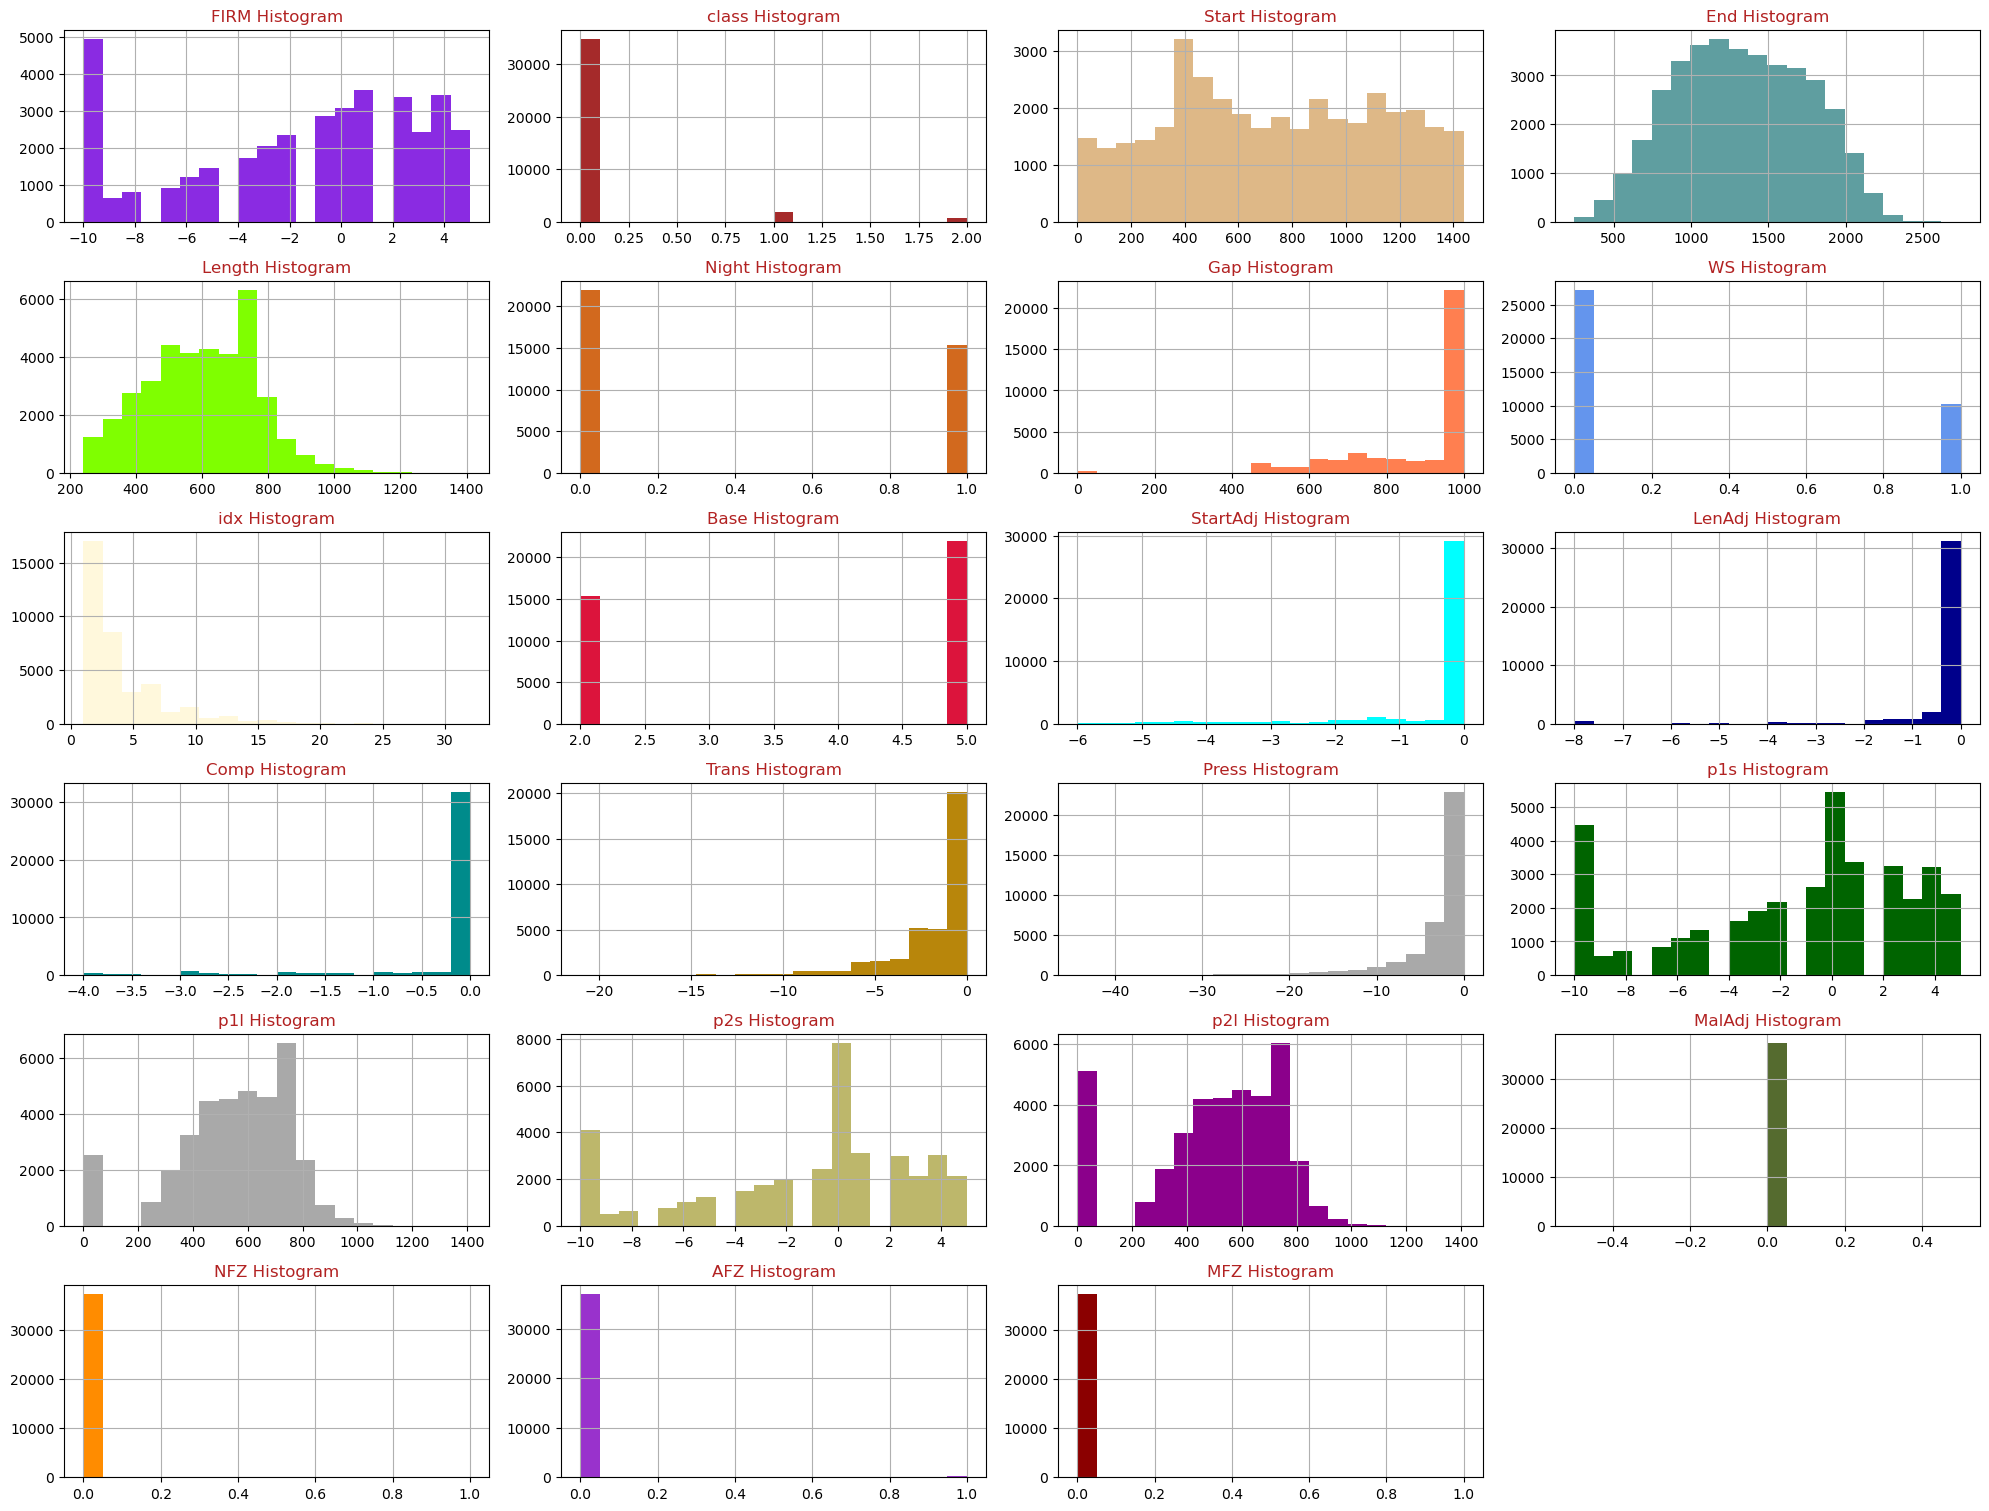

In [339]:
def chartDifferences(dataFrame, log = False):
    import matplotlib.colors as mcolors
    colors = list(mcolors.CSS4_COLORS.keys())[10:]
    fig = plt.figure(figsize=(20,20))
    for i, feature in enumerate(dataFrame.columns):
        f = fig.add_subplot(8, 4, i + 1)
        dataFrame[feature].hist(bins = 20, ax = f, facecolor = colors[i])
        f.set_title(feature + " Histogram", color = colors[35])
        if log:
            f.set_yscale('log')
    fig.tight_layout()
    plt.show()
chartDifferences(df)

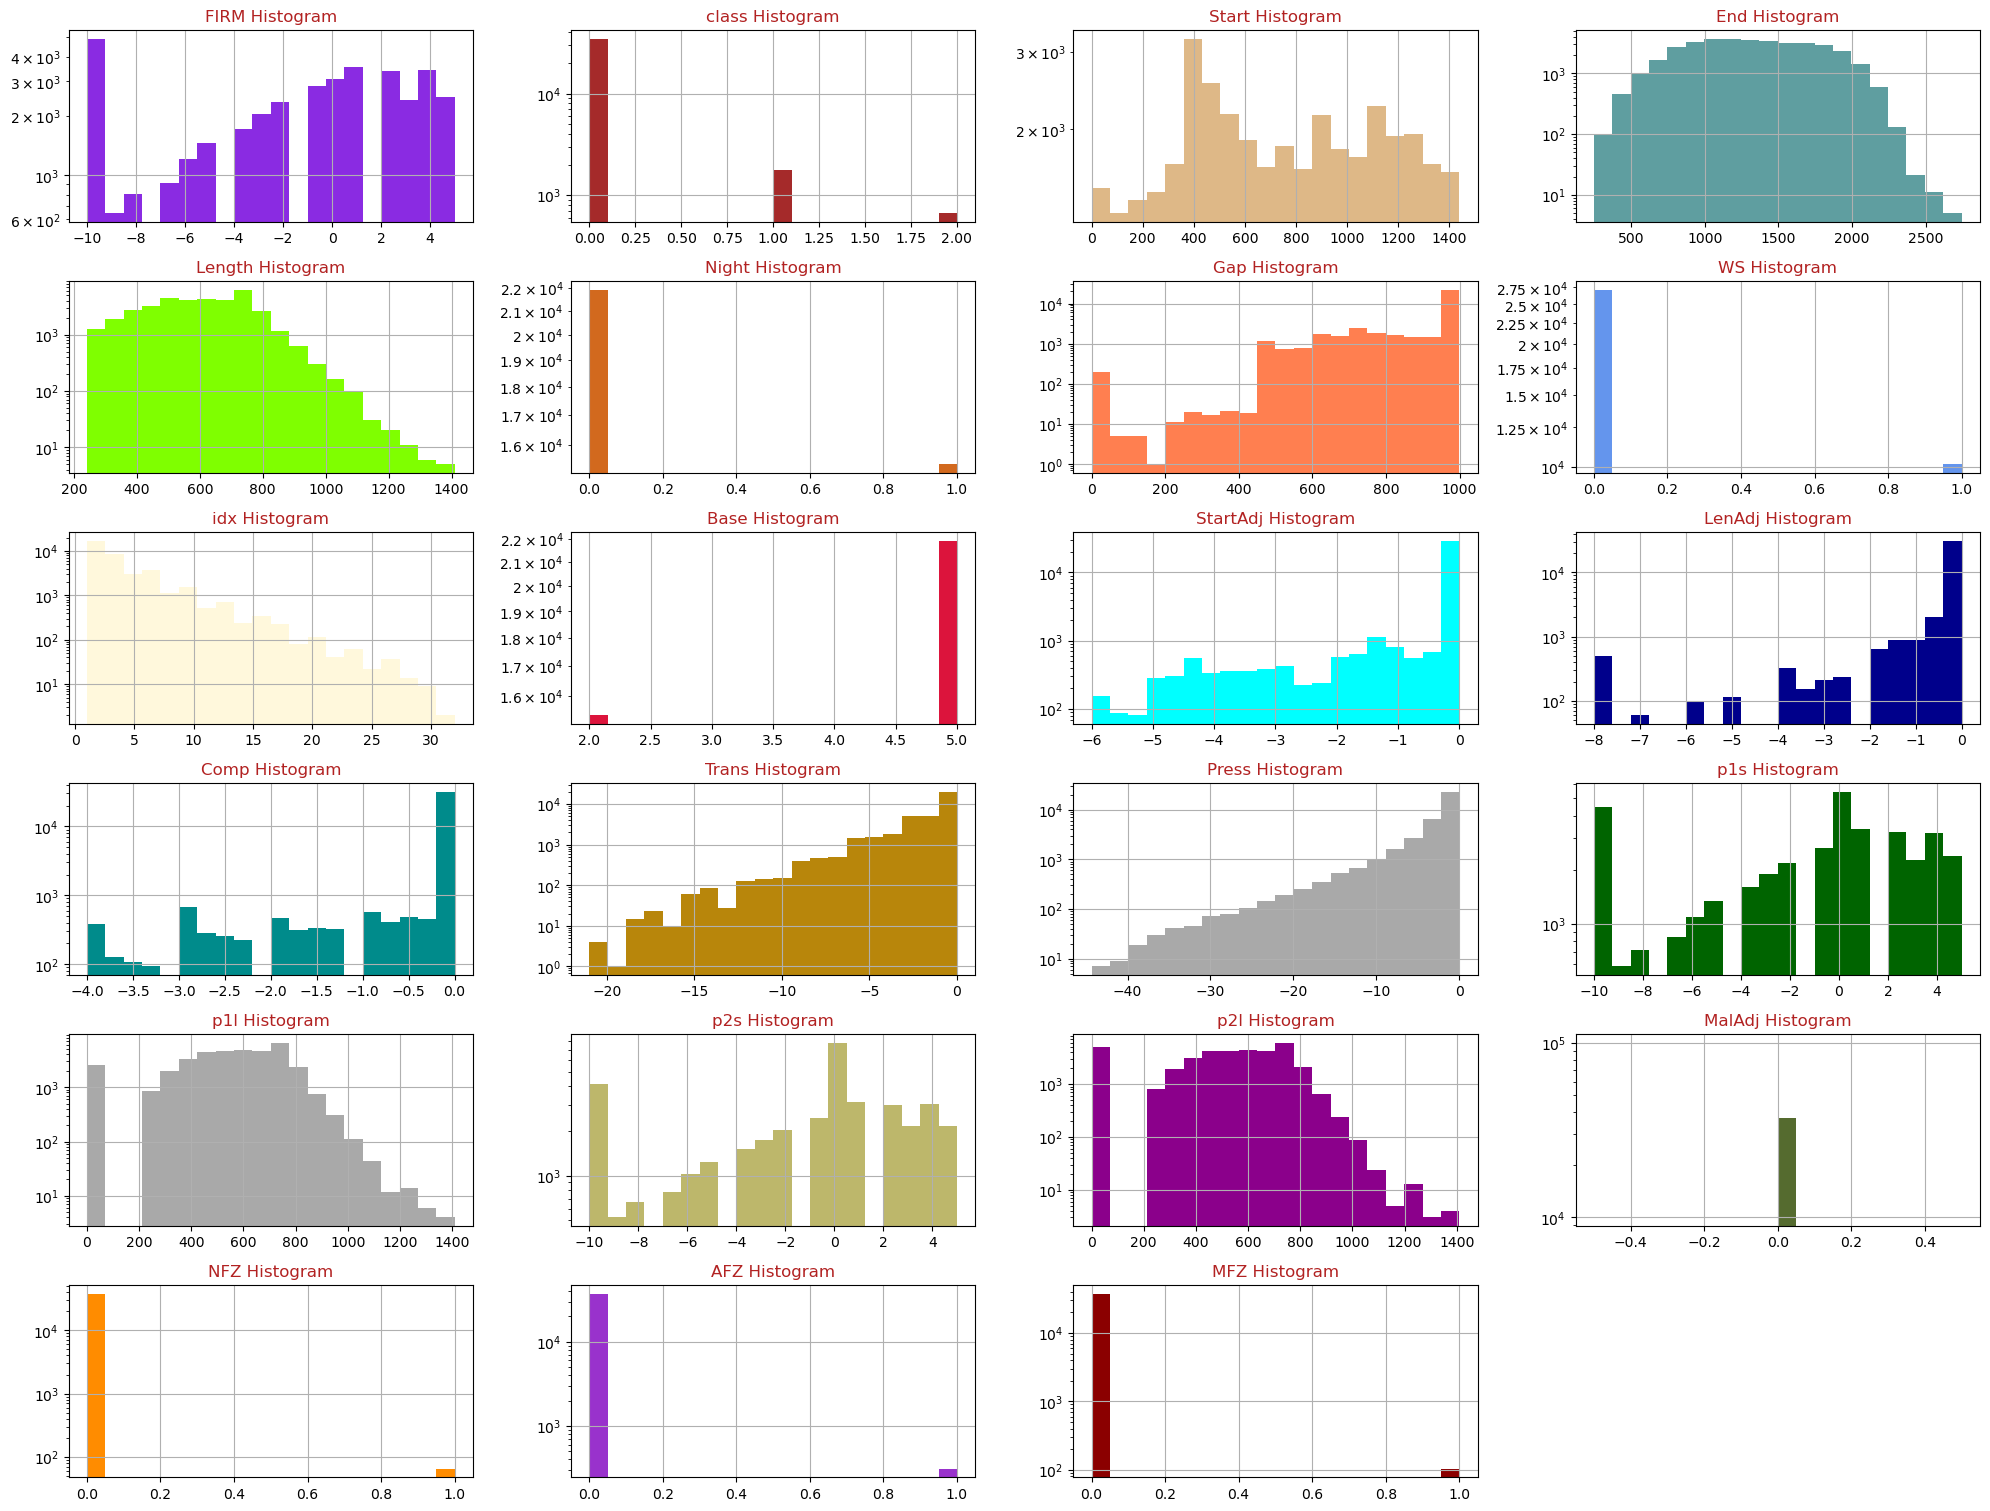

In [340]:
chartDifferences(df, log=True)

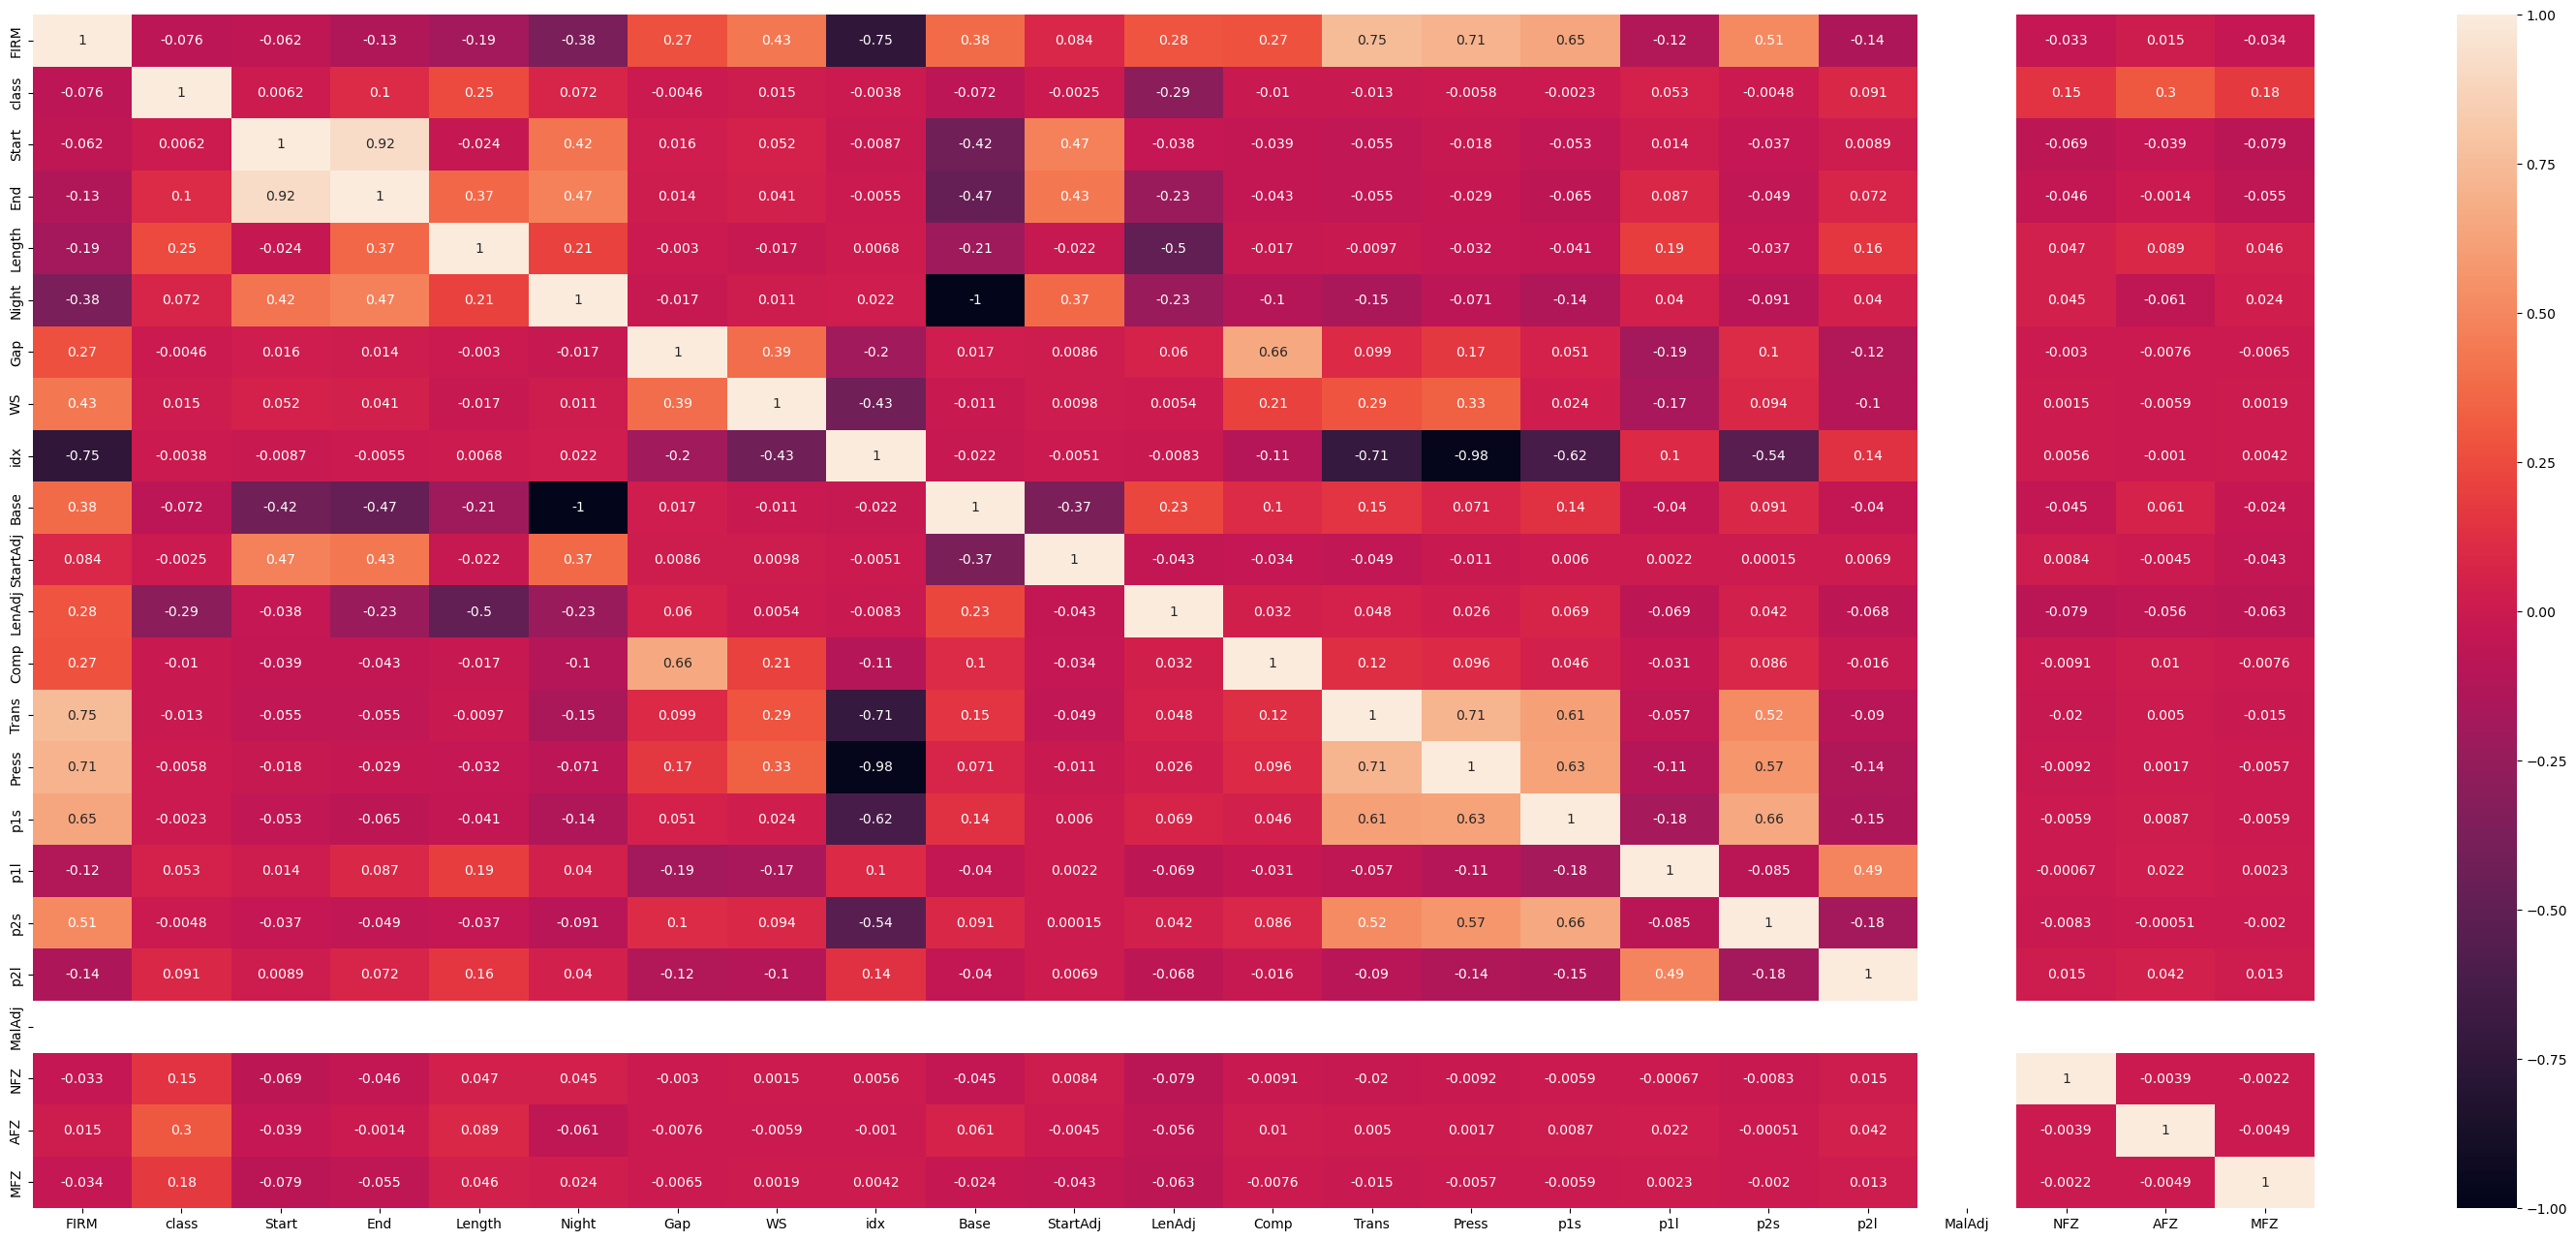

In [341]:
plt.figure(figsize = (38, 16))
sns.heatmap(df.corr(), annot = True)
plt.show()

Before Data Analysis:

In the historgrams, it seems that there are quite a few external variables that go into the data inputs. For example, FIRM, p1s and p2s have nearly the same distribution. And so does p1l and p2l. This is also fairly highlighted in the heatmap aswell. Additionally, it sleems that Length has the highest correlation to Class, which is also interesting.

It also seems that MalAdj has no data, so I'm probably going to drop that from the data aswell.

There seems to be major correlation between Base and Night, as well as Press and idx. Also, there is additional correlation with FIRM and Trans, Press, p1s, p2s, idx,, and additional correlation with Trans and Press.

Additionally, Start and End should be dropped since they vary incredibly dependant on a particular worker's shift. It would be better to do analysis on Length, or Start End Adjusted.

In [342]:
df.drop('MalAdj', axis=1, inplace=True)
df.drop('Start', axis=1, inplace=True)
df.drop('End', axis=1, inplace=True)

Question: Are the two types of accidents distinguishable?

I think to answer this, I could do a comparative analysis between type 1 and type 2 accidents. I'm thinking about a Two-Sample-Z-Test on each column to see if there are differences in the means of each data point.

I expect that if the means and distributions are similar, then that datapoint is common to both distribution.

In [343]:
import statsmodels.stats.weightstats as stats
df_accident_one = df.loc[df['class'] == 1]#.sample(n=30)
df_accident_two = df.loc[df['class'] == 2]#.sample(n=30)
# df_accident_one.drop('class', axis=0, inplace=True)
# df_accident_two.drop('class', axis=0, inplace=True)

z_test_output = []

for column in df.columns:
    z_val, p_val = stats.ztest(df_accident_one[column], df_accident_two[column])
    print(f"{column}: {z_val:.4f}, {p_val:.4f}")


FIRM: -0.7423, 0.4579
class: -inf, 0.0000
Length: 3.3841, 0.0007
Night: 0.2290, 0.8188
Gap: 0.8195, 0.4125
WS: 0.1433, 0.8860
idx: -1.3761, 0.1688
Base: -0.2290, 0.8188
StartAdj: -1.5403, 0.1235
LenAdj: -0.3772, 0.7060
Comp: -0.7599, 0.4473
Trans: -0.0682, 0.9456
Press: 1.5498, 0.1212
p1s: 1.2664, 0.2054
p1l: -0.9608, 0.3366
p2s: 0.5867, 0.5574
p2l: -0.6555, 0.5121
NFZ: 0.2686, 0.7882
AFZ: 3.3972, 0.0007
MFZ: 1.4182, 0.1561


/home/oreomilkshake/anaconda3/lib/python3.12/site-packages/statsmodels/stats/weightstats.py:748: RuntimeWarning: divide by zero encountered in scalar divide
  zstat = (value1 - value2 - diff) / std_diff


Doing a Two-Sample-Z-Test on every column for a sample between Class 1 and Class 2 errors does not demonstrate any significant difference between the two. For most of the data, it does not seem that there are significant factors at the 10% level that would indicate that there is generally a higher variable for one class of accident to another. Additionally, there are a few variables that have a very low sampling rate, so it will also be slightly difficult to conclude any differences between them.

Additionally, running this test multiple times changes variable statistics, so there is likeliness that this sample is not fully representative of the population.

So I reran the test against the whole population...
And it seems that two variabels stick out: Length and AFZ. I'm going to ignore AFZ for now, since it seems like a "true / false" flag, but Length on the otherhand might indicate something...

,FIRM,class,Length,Night,Gap,WS,idx,Base,StartAdj,LenAdj,Comp,Trans,Press,p1s,p1l,p2s,p2l,NFZ,AFZ,MFZ
count,665.000000,665.0,665.000000,665.000000,665.000000,665.000000,665.000000,665.000000,665.000000,665.000000,665.000000,665.000000,665.00000,665.000000,665.000000,665.000000,665.000000,665.000000,665.000000,665.000000
mean,-2.954887,2.0,747.518797,0.551880,873.839098,0.297744,4.169925,3.344361,-0.500752,-1.746541,-0.293985,-2.135564,-3.54415,-1.600000,597.491729,-1.452632,598.742857,0.025564,0.090226,0.033083
std,4.889848,0.0,193.524609,0.497676,181.424126,0.457611,4.659134,1.493027,1.193765,2.623418,0.805105,2.910230,6.50495,4.604804,161.788024,4.616425,166.868198,0.157949,0.286720,0.178987
min,-10.000000,2.0,255.000000,0.000000,0.000000,0.000000,1.000000,2.000000,-5.750000,-8.000000,-4.000000,-20.000000,-42.50000,-10.000000,244.000000,-10.000000,0.000000,0.000000,0.000000,0.000000
25%,-8.000000,2.0,635.000000,0.000000,740.000000,0.000000,1.000000,2.000000,0.000000,-2.500000,0.000000,-3.000000,-3.33000,-4.000000,475.000000,-5.000000,475.000000,0.000000,0.000000,0.000000
50%,-2.000000,2.0,745.000000,1.000000,999.000000,0.000000,3.000000,2.000000,0.000000,-0.380000,0.000000,-1.000000,-1.33000,-1.000000,610.000000,0.000000,615.000000,0.000000,0.000000,0.000000
75%,1.000000,2.0,860.000000,1.000000,999.000000,1.000000,5.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.00000,2.000000,720.000000,2.000000,720.000000,0.000000,0.000000,0.000000
max,5.000000,2.0,1380.000000,1.000000,999.000000,1.000000,32.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.00000,5.000000,1115.000000,5.000000,1160.000000,1.000000,1.000000,1.000000


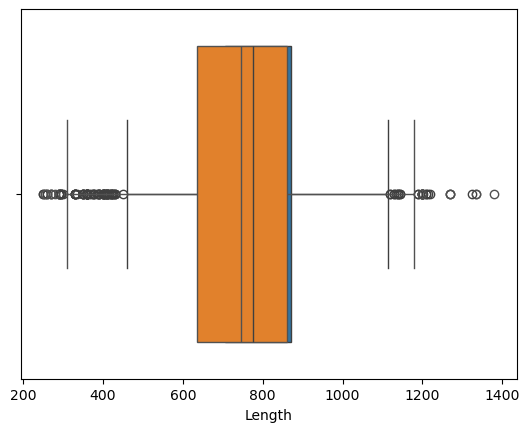

In [344]:
sns.boxplot(data=df_accident_one, x = 'Length')
sns.boxplot(data=df_accident_two, x = 'Length')
df_accident_one.describe()
df_accident_two.describe()

,FIRM,class,Length,Night,Gap,WS,idx,Base,StartAdj,LenAdj,Comp,Trans,Press,p1s,p1l,p2s,p2l,NFZ,AFZ,MFZ
count,1681.00000,1681.0,1681.000000,1681.000000,1681.000000,1681.000000,1681.000000,1681.000000,1681.000000,1681.000000,1681.000000,1681.000000,1681.000000,1681.000000,1681.000000,1681.000000,1681.000000,1681.000000,1681.000000,1681.000000
mean,-3.20583,1.0,786.099346,0.572873,878.760857,0.302201,3.938727,3.281380,-0.585961,-1.793974,-0.334474,-2.165747,-3.193617,-1.358120,589.736466,-1.360500,595.190958,0.027960,0.140988,0.046401
std,4.78706,0.0,129.235915,0.494808,172.629820,0.459349,3.961924,1.484425,1.354518,2.493457,0.895136,2.651592,5.399458,4.718657,161.678245,4.682384,165.348481,0.164906,0.348112,0.210414
min,-10.00000,1.0,460.000000,0.000000,0.000000,0.000000,1.000000,2.000000,-6.000000,-8.000000,-4.000000,-20.000000,-43.000000,-10.000000,0.000000,-10.000000,0.000000,0.000000,0.000000,0.000000
25%,-8.00000,1.0,715.000000,0.000000,750.000000,0.000000,1.000000,2.000000,0.000000,-2.500000,0.000000,-3.000000,-3.500000,-4.000000,480.000000,-4.000000,480.000000,0.000000,0.000000,0.000000
50%,-3.00000,1.0,780.000000,1.000000,999.000000,0.000000,3.000000,2.000000,0.000000,-0.620000,0.000000,-1.330000,-1.330000,0.000000,600.000000,0.000000,605.000000,0.000000,0.000000,0.000000
75%,1.00000,1.0,870.000000,1.000000,999.000000,1.000000,5.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,719.000000,2.000000,720.000000,0.000000,0.000000,0.000000
max,5.00000,1.0,1115.000000,1.000000,999.000000,1.000000,29.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,1375.000000,5.000000,1260.000000,1.000000,1.000000,1.000000


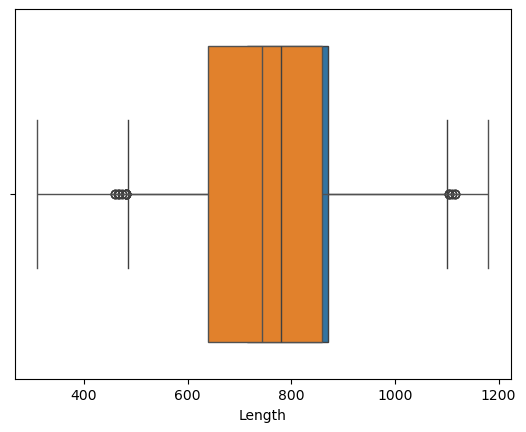

In [345]:
def removeOutliersIQR(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

df_accident_one = removeOutliersIQR(df_accident_one, 'Length')
df_accident_two = removeOutliersIQR(df_accident_two, 'Length')
sns.boxplot(df_accident_one, x = 'Length')
sns.boxplot(df_accident_two, x = 'Length')
df_accident_one.describe()

In [346]:
z_val, p_val = stats.ztest(df_accident_one['Length'], df_accident_two['Length'])
print(f"{'Length'}: {z_val:.4f}, {p_val:.4f}")

Length: 5.9576, 0.0000


This removed major outliers in the Length column, but it still seems that the Z score is even more unlikely, likely due to the sheer amount of samples gathered. Perhaps we could hypothesize that the different types of accidents could be classified by Length.

Here, I want to test to see if a Logistic Regression could pick up on patterns such as these, and accurately classify Class 1 and Class 2 Accidents.

In [347]:
df_accidents = df.loc[df['class'] >= 1]
categ = np.array(df_accidents['class']).astype(int)
print(categ)
# y = df_accidents.iloc[:, df_accidents.columns == 'class']
X = df_accidents.iloc[:, df_accidents.columns != 'class']

X_train, X_test, y_train, y_test = train_test_split(X, categ, test_size=0.33, random_state=5)

scaler = preprocessing.StandardScaler().fit(X_train)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns = X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns = X_test.columns)

[1 1 2 ... 1 1 1]


In [348]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = model.score(X_test_scaled, y_test)
print(f"Train Accuracy: {100 * train_accuracy:.2f}%, Test accuracy: {100 * test_accuracy:.2f}%")

[1 1 2 ... 1 1 1]
Train Accuracy: 73.85%, Test accuracy: 70.63%


A binary Logistic Regression has a test accuracy of ~70% when classifying Class 1 and Class 2 accidents. This is fairly decent, so it does hint of the possibility that the two types of classifications are not indistinguishable and may have general patterns that sets them apart.

In [349]:
probs = model.predict_proba(X_test_scaled)
np.set_printoptions(precision=4, suppress=True)
probs[:10]

array([[0.8328, 0.1672],
       [0.7076, 0.2924],
       [0.7102, 0.2898],
       [0.8489, 0.1511],
       [0.7299, 0.2701],
       [0.7336, 0.2664],
       [0.7748, 0.2252],
       [0.8425, 0.1575],
       [0.7812, 0.2188],
       [0.7021, 0.2979]])

In [350]:
from sklearn import metrics
#confusion matrix
def makeConfusionMatrix(result, answer, normalized=False):
    total_samples = len(answer)
    print(f"classification accuracy: {100 * metrics.accuracy_score(result, answer):.2f}%")
    print(f"confusion matrix:\n {metrics.confusion_matrix(result, answer)}")
    # plt.figure(figsize = (38, 16))
    # sns.heatmap(metrics.confusion_matrix(result, answer), annot = True)
    # plt.show()
X_scaled = pd.DataFrame(scaler.transform(X), columns = X.columns)
yhat = model.predict(X_scaled)
makeConfusionMatrix(yhat, categ)
# X_scaled.eval

# should look something like this
#                       NoA AT1 AT2
#                   NoA
# Prediction        AT1
#                   AT2
#                   

classification accuracy: 72.79%
confusion matrix:
 [[1775  661]
 [   4    4]]


The results from this confusion matrix is quite poor. While it can reliably create True Positives for Class A type accidents, it nearly classifies all Class B accidents as Class A, which is far from optimal.

Therefore, it is likely that Class A and Class B accidents are likely indistinguishable.

Question 2: Accurately does the regressor classify models?
This will mean a confusion matrix for no accident vs accident.

In [380]:
categ = np.array(df['class'] > 0).astype(int)
print(categ)
y = df.iloc[:, df.columns == 'class']
X = df.iloc[:, df.columns != 'class']

X_train, X_test, y_train, y_test = train_test_split(X, categ, test_size=0.33, random_state=5)

scaler = preprocessing.StandardScaler().fit(X_train)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns = X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns = X_test.columns)

[0 0 0 ... 0 0 1]


In [381]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = model.score(X_test_scaled, y_test)
print(f"Train Accuracy: {100 * train_accuracy:.2f}%, Test accuracy: {100 * test_accuracy:.2f}%")

Train Accuracy: 94.93%, Test accuracy: 94.85%


In [383]:
X_scaled = pd.DataFrame(scaler.transform(X), columns = X.columns)
yhat = model.predict(X_scaled)
makeConfusionMatrix(yhat, categ)

classification accuracy: 94.91%
confusion matrix:
 [[34726  1764]
 [  136   680]]


So the classification has a 94% accuracy in both its train, test, and population classification. However, this also shows that the probability of correctly identifying an accident is only ~39%, which is also very poor.